# Bivariate models and fit diagnostics

Compare constant MLE, score-driven GAS, and latent SCAR-TM-OU fits. This
notebook focuses on estimator diagnostics and dynamic dependence; the basic
API lifecycle is left in `01_basic_api.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from pyscarcopula._utils import pobs
from pyscarcopula import GumbelCopula
from pyscarcopula.api import fit, predict, predictive_mean
from pyscarcopula.stattests import gof_test

## Data and fit parameters

In [2]:
TICKERS = ["BTC-USD", "ETH-USD"]
FIT_CONFIGS = {
    "MLE": {"method": "mle"},
    "GAS": {"method": "gas"},
    "SCAR-TM": {"method": "scar-tm-ou"},
}
SEED = 2026

DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
prices = pd.read_csv(DATA_DIR / "crypto_prices.csv", index_col=0, sep=";")
returns = np.log(prices[TICKERS] / prices[TICKERS].shift(1)).dropna()
u = pobs(returns.to_numpy())
copula = GumbelCopula(rotate=180)

## Fit and compare estimators

In [3]:
results = {
    name: fit(copula, u, **kwargs)
    for name, kwargs in FIT_CONFIGS.items()
}

comparison = pd.DataFrame({
    name: {
        "method": result.method,
        "success": result.success,
        "log_likelihood": result.log_likelihood,
        "n_params": result.n_params,
        "nfev": result.nfev,
    }
    for name, result in results.items()
}).T
comparison["gof_pvalue"] = {
    name: gof_test(
        copula, u, fit_result=result, to_pobs=False
    ).pvalue
    for name, result in results.items()
}
comparison

,method,success,log_likelihood,n_params,nfev,gof_pvalue
MLE,MLE,True,955.627508,1,5,0.010494
GAS,GAS,True,1041.728756,3,144,0.670619
SCAR-TM,SCAR-TM-OU,True,1045.779882,3,10,0.712486


## Inspect fit diagnostics

Every fit result exposes convergence fields (`success`, `nfev`, `message`) and
a method-specific `diagnostics` mapping. Flattening it makes backend,
initialisation, gradient, fallback, and final-validation decisions easy to
filter.

In [4]:
scar_result = results["SCAR-TM"]
scar_diagnostics = scar_result.diagnostics

pd.Series({
    key: value
    for key, value in scar_diagnostics.items()
    if any(token in key for token in (
        "initialization", "engine", "gradient",
        "fallback", "validation",
    ))
}, name="value")

matrix_fallback_unknown                                                               0
fallback_spectral_to_matrix                                                           0
fallback_matrix_to_local                                                              0
selected_engine                                                                     cpp
initialization                        {'requested_method': 'strength_aware', 'select...
optimizer_gradient                                                           analytical
gradient_kind                                                                analytical
prepared_native_fallback                                                           None
last_engine                                                                         cpp
final_validation_passed                                                            True
final_validation_reasons                                                             ()
final_selected_engine           

In [5]:
gas_diagnostics = results["GAS"].diagnostics
pd.Series({
    key: value
    for key, value in gas_diagnostics.items()
    if any(token in key for token in ("score", "gradient", "engine"))
}, name="value")

model_score                        native
optimizer_gradient              numerical
gradient_kind         numerical_optimizer
Name: value, dtype: str

## Dynamic parameter paths

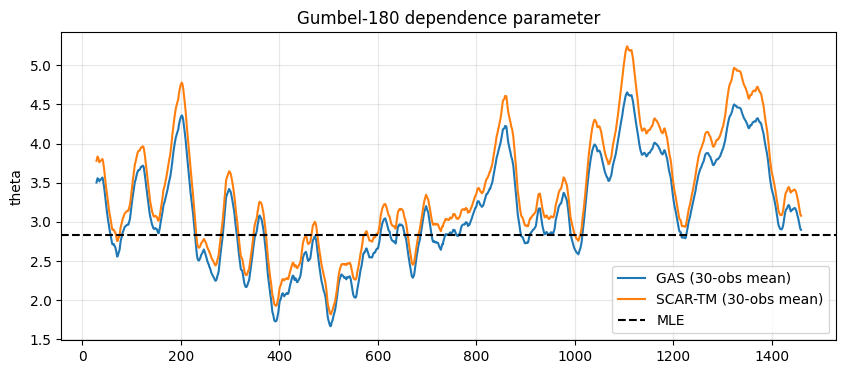

In [6]:
paths = {
    name: predictive_mean(copula, u, result)
    for name, result in results.items()
}

fig, ax = plt.subplots(figsize=(10, 4))
window = 30
for name in ("GAS", "SCAR-TM"):
    ax.plot(
        pd.Series(paths[name]).rolling(window).mean(),
        label=f"{name} ({window}-obs mean)",
    )
ax.axhline(paths["MLE"][0], color="black", linestyle="--", label="MLE")
ax.set(title="Gumbel-180 dependence parameter", ylabel="theta")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Predictive horizons

In [7]:
current_u = predict(
    copula,
    u,
    scar_result,
    n=5_000,
    horizon="current",
    rng=np.random.default_rng(SEED),
)
next_u = predict(
    copula,
    u,
    scar_result,
    n=5_000,
    horizon="next",
    rng=np.random.default_rng(SEED + 1),
)

pd.DataFrame(
    [current_u.mean(axis=0), next_u.mean(axis=0)],
    index=["current", "next"],
    columns=TICKERS,
)

,BTC-USD,ETH-USD
current,0.505823,0.510958
next,0.499345,0.501758


## Optional bootstrap GoF diagnostics

Parametric bootstrap is more expensive because it can refit every simulated
sample. The returned object records per-replication fit status, parameters,
timings, and test statistics.

In [8]:
RUN_BOOTSTRAP = False

if RUN_BOOTSTRAP:
    bootstrap_gof = gof_test(
        copula,
        u,
        fit_result=results["MLE"],
        to_pobs=False,
        bootstrap=True,
        n_bootstrap=49,
        bootstrap_refit=True,
        rng=SEED,
    )
    display(pd.DataFrame(bootstrap_gof.bootstrap_diagnostics).head())
    print("bootstrap p-value:", bootstrap_gof.pvalue)